# Дифференцирование

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы: 
* https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.axhline.html#matplotlib.pyplot.axhline
* https://numpy.org/doc/stable/reference/generated/numpy.log1p.html#numpy.log1p
* https://docs.sympy.org/latest/tutorials/intro-tutorial/calculus.html
* https://en.wikipedia.org/wiki/Finite_difference
* https://pythonnumericalmethods.berkeley.edu/notebooks/chapter20.02-Finite-Difference-Approximating-Derivatives.html
* https://en.wikipedia.org/wiki/Gradient_descent
* https://pytorch.org/tutorials/beginner/blitz/autograd_tutorial.html
* https://zhang-yang.medium.com/the-gradient-argument-in-pytorchs-backward-function-explained-by-examples-68f266950c29

## Задачи для совместного разбора

1\. Дана функция $f(x) = x^2$. Найдите производную этой функции различными способами

## Задачи для самостоятельного решения

In [3]:
import torch as th
import matplotlib.pyplot as plt

<p class="task" id="1"></p>

1\. Дана функция $f(x)$. Найдите (аналитически) производную данной функции $f'(x)$ и реализуйте две этих функции. Постройте в одной системе координат графики $f(x)$, $f'(x)$ и $g(x) = 0$ на отрезке [1, 10]. Изобразите графики различными цветами и включите сетку. 

$$f(x) = \frac{sin(x)}{\ln(x) + 1}$$

- [ ] Проверено на семинаре

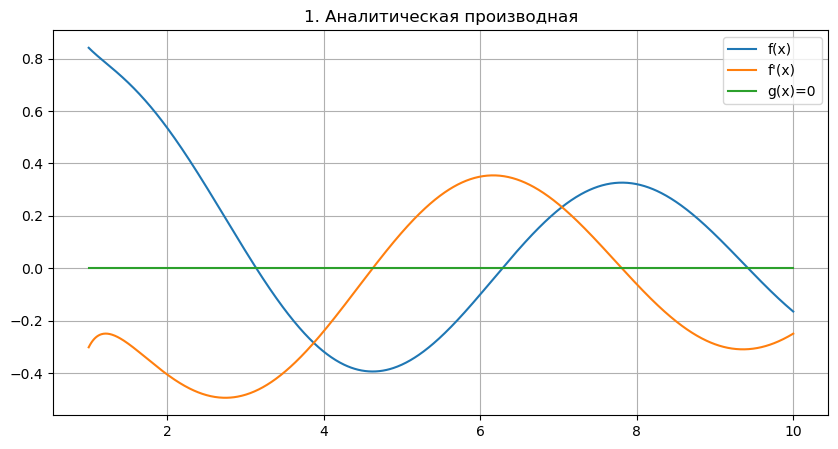

In [4]:
def f(x: th.Tensor) -> th.Tensor:
    return th.sin(x) / (th.log(x) + 1)


def df_analytic(x: th.Tensor) -> th.Tensor:
    return (th.cos(x) * (th.log(x) + 1) - th.sin(x) / x) / (th.log(x) + 1) ** 2


x1 = th.linspace(1, 10, 1000)
y1 = f(x1)
dy1 = df_analytic(x1)
zero1 = th.zeros_like(x1)

plt.figure(figsize=(10, 5))
plt.plot(x1.numpy(), y1.numpy(), label='f(x)')
plt.plot(x1.numpy(), dy1.numpy(), label="f'(x)")
plt.plot(x1.numpy(), zero1.numpy(), label='g(x)=0')
plt.grid(True)
plt.legend()
plt.title("1. Аналитическая производная")
plt.show()

<p class="task" id="2"></p>

2\. Дана функция $f(x)$. Найдите (численно) производную данной функции $f'(x)$ на отрезке [1, 10]. Постройте в одной системе координат график $f(x)$, $f'(x)$ и $g(x) = 0$. Изобразите графики различными цветами и включите сетку. 

$$f(x) = \frac{sin(x)}{\ln(x) + 1}$$

- [ ] Проверено на семинаре

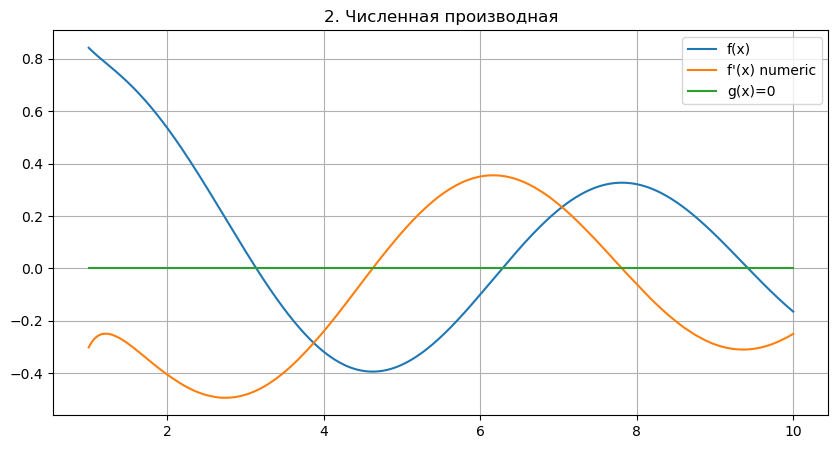

In [5]:
def df_numeric(x: th.Tensor, eps: float = 1e-4) -> th.Tensor:
    return (f(x + eps) - f(x - eps)) / (2 * eps)


x2 = th.linspace(1, 10, 1000)
y2 = f(x2)
dy2 = df_numeric(x2)
zero2 = th.zeros_like(x2)

plt.figure(figsize=(10, 5))
plt.plot(x2.numpy(), y2.numpy(), label='f(x)')
plt.plot(x2.numpy(), dy2.numpy(), label="f'(x) numeric")
plt.plot(x2.numpy(), zero2.numpy(), label='g(x)=0')
plt.grid(True)
plt.legend()
plt.title("2. Численная производная")
plt.show()


<p class="task" id="3"></p> 


3\. Найдите локальный минимум функции $f(x)$ при помощи метода градиентного спуска. В качестве начальной точки используйте $x_0 = 4$. Найдите локальный максимум этой же функции, используя в качестве начальной точки $x_0'=9$. $$f(x) = \frac{sin(x)}{\ln(x) + 1}$$

In [6]:
def grad_descent(x0, lr=0.1, steps=200):
    x = th.tensor([x0], dtype=th.float32, requires_grad=True)
    for _ in range(steps):
        y = f(x)
        y.backward()
        with th.no_grad():
            x -= lr * x.grad
        x.grad.zero_()
    return x.detach(), f(x.detach())


def grad_ascent(x0, lr=0.1, steps=200):
    x = th.tensor([x0], dtype=th.float32, requires_grad=True)
    for _ in range(steps):
        y = f(x)
        y.backward()
        with th.no_grad():
            x += lr * x.grad
        x.grad.zero_()
    return x.detach(), f(x.detach())


xmin, ymin = grad_descent(4.0)
xmax, ymax = grad_ascent(9.0)

print("3. Локальный минимум:")
print("x_min =", xmin.item())
print("f(x_min) =", ymin.item())

print("\n3. Локальный максимум:")
print("x_max =", xmax.item())
print("f(x_max) =", ymax.item())

3. Локальный минимум:
x_min = 4.627009391784668
f(x_min) = -0.39351993799209595

3. Локальный максимум:
x_max = 7.814035415649414
f(x_max) = 0.32697248458862305


<p class="task" id="4"></p> 

4\. Дана функция $f(x)$. Найдите (используя возможности по автоматическому дифференцированию пакета torch) производную данной функции $f'(x)$ на отрезке [0, 10]. Постройте в одной системе координат график $f(x)$, $f'(x)$ и $g(x) = 0$ на полуинтервале (0, 10]. Изобразите графики различными цветами и включите сетку.

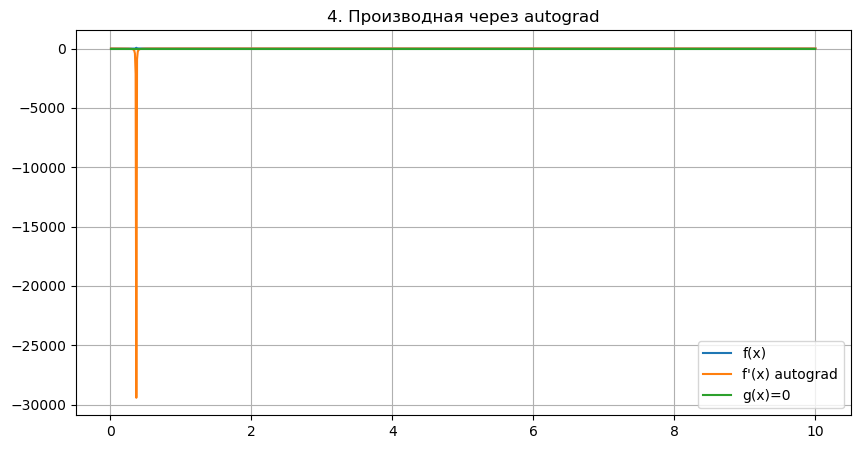

In [7]:
x4 = th.linspace(0.01, 10, 1000, requires_grad=True)
y4 = f(x4)

dy4 = []
for i in range(len(x4)):
    if x4.grad is not None:
        x4.grad.zero_()
    y4[i].backward(retain_graph=True)
    dy4.append(x4.grad[i].item())

dy4 = th.tensor(dy4)
zero4 = th.zeros_like(x4.detach())

plt.figure(figsize=(10, 5))
plt.plot(x4.detach().numpy(), y4.detach().numpy(), label='f(x)')
plt.plot(x4.detach().numpy(), dy4.numpy(), label="f'(x) autograd")
plt.plot(x4.detach().numpy(), zero4.numpy(), label='g(x)=0')
plt.grid(True)
plt.legend()
plt.title("4. Производная через autograd")
plt.show()

<p class="task" id="5"></p>

5\. Дана функция $f(x)$. Найдите производную данной функции $f'(x)$ на отрезке [0, 10] при помощи формулы производной сложной функции. На этом же отрезке найдите, используя возможности по автоматическому дифференцированию пакета `torch`. Сравните результаты.

$$f(x) = sin(cos(x))$$

- [ ] Проверено на семинаре

In [8]:
def g(x: th.Tensor) -> th.Tensor:
    return th.cos(x)

def h(x: th.Tensor) -> th.Tensor:
    return th.sin(x)

def dfdg(x: th.Tensor) -> th.Tensor:
    return th.cos(g(x))

def dgdx(x: th.Tensor) -> th.Tensor:
    return -th.sin(x)

def dfdx(x: th.Tensor) -> th.Tensor:
    return dfdg(x) * dgdx(x)


5. Максимальная абсолютная разница между формулой и autograd:
0.0


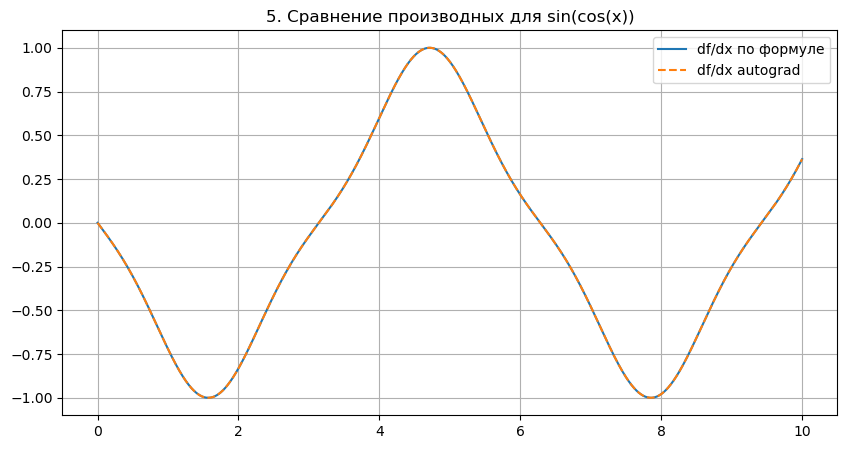

In [9]:
x5 = th.linspace(0, 10, 1000, requires_grad=True)
y5 = h(g(x5))

dy5_auto = []
for i in range(len(x5)):
    if x5.grad is not None:
        x5.grad.zero_()
    y5[i].backward(retain_graph=True)
    dy5_auto.append(x5.grad[i].item())

dy5_auto = th.tensor(dy5_auto)
dy5_formula = dfdx(x5.detach())

print("\n5. Максимальная абсолютная разница между формулой и autograd:")
print(th.max(th.abs(dy5_formula - dy5_auto)).item())

plt.figure(figsize=(10, 5))
plt.plot(x5.detach().numpy(), dy5_formula.numpy(), label="df/dx по формуле")
plt.plot(x5.detach().numpy(), dy5_auto.numpy(), '--', label="df/dx autograd")
plt.grid(True)
plt.legend()
plt.title("5. Сравнение производных для sin(cos(x))")
plt.show()